# Stanford CME 241 (Winter 2026) - Assignment 3

**Due: Friday, February 27 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo:* 

https://github.com/onat-dalmaz/RL-book/blob/master/Assignments/Assignment%203/hw3.ipynb

*Group members (replace below names with people in your group):* 
- Onat Dalmaz

## Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from typing import Iterable, Iterator, Mapping, TypeVar, Callable, Sequence, Tuple, Dict

# Ensure RL-book repo root is on path so we can import rl
def _add_repo_root() -> None:
    p = Path.cwd()
    while p != p.parent and not (p / "rl").is_dir():
        p = p.parent
    if (p / "rl").is_dir() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
_add_repo_root()

from rl.distribution import Categorical
from rl.markov_process import FiniteMarkovRewardProcess
from rl.chapter10.prediction_utils import compare_td_and_mc
X = TypeVar('X')
S = TypeVar('S')

## Question 1: Milk Vendor Optimization Problem (Led by Onat Dalmaz)

You are a milk vendor and your task is to bring to your store a supply (denoted $S \in \mathbb{R}$) of milk volume in the morning that will give you the best profits. You know that the demand for milk throughout the course of the day is a probability distribution function $f$ (for mathematical convenience, assume people can buy milk in volumes that are real numbers, hence milk demand $x \in \mathbb{R}$ is a continuous variable with a probability density function). 

For every extra gallon of milk you carry at the end of the day (supply $S$ exceeds random demand $x$), you incur a cost of $h$ (effectively the wasteful purchases amounting to the difference between your purchase price and the end-of-day discount disposal price since you are not allowed to sell the same milk the next day). For every gallon of milk that a customer demands that you don’t carry (random demand $x$ exceeds supply $S$), you incur a cost of $p$ (effectively the missed sales revenue amounting to the difference between your sales price and purchase price). 

Your task is to identify the optimal supply $S$ that minimizes your **Expected Cost** $g(S)$, given by:

$$
g_1(S) = \mathbb{E}[\max(x - S, 0)] = \int_{S}^{\infty} (x - S) \cdot f(x) \, dx
$$

$$
g_2(S) = \mathbb{E}[\max(S - x, 0)] = \int_{-\infty}^{S} (S - x) \cdot f(x) \, dx
$$

$$
g(S) = p \cdot g_1(S) + h \cdot g_2(S)
$$

***

### Part (A): Analytical Optimization

1. **Derive the first-order condition (FOC)** for minimizing the expected cost $g(S)$.
2. **Solve the FOC** to express the optimal supply $S^*$ in terms of the given parameters: $p$, $h$, and the demand distribution $f(x)$. (*Hint*: Pay attention to the balance between the costs of overstocking and understocking)

3. **Interpretation**: Provide an interpretation of the condition you derived. What does the balance between $p$ and $h$ imply about the optimal supply $S^*$?

***

### Part (B): Special Case Analysis

1. Consider the case where the demand $x$ follows an **exponential distribution** with parameter $\lambda > 0$. That is, $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$.
    - Derive an explicit expression for the optimal supply $S^*$.
    
2. Consider the case where the demand $x$ follows a **normal distribution** with mean $\mu$ and variance $\sigma^2$, i.e., $x \sim \mathcal{N}(\mu, \sigma^2)$. 
    - Set up the integral for $g(S)$ and describe how it relates to the **cumulative distribution function (CDF)** of the normal distribution.
    - Provide an interpretation of how changes in $\mu$ and $\sigma$ influence the optimal $S^*$. 

***

### Part (C): Framing as a Financial Options Problem

1. Frame the milk vendor’s problem as a **portfolio of call and put options**:
    - Identify the analog of the “strike price” and “underlying asset.”
    - Explain which part of the cost function $g_1(S)$ or $g_2(S)$ corresponds to a call option and which part to a put option.
    - What do $p$ and $h$ represent in this options framework?

2. Explain how this framing could be used to derive the optimal supply $S^*$ if solved using financial engineering concepts.

***

### Part (D): Numerical Solution and Simulation

1. **Numerical Solution**: Write a Python function that numerically estimates the optimal $S^*$ using an iterative search or numerical optimization method. 

2. **Simulation**: Generate random samples of milk demand from an exponential distribution and simulate the total costs for different values of $S$. Plot the costs against $S$ and visually identify the optimal $S$.

### Part (A) Answer

Let $F(S)=\int_{-\infty}^{S} f(x)\,dx$ be the CDF.

Using Leibniz’ rule:
- $$g_1(S)=\int_{S}^{\infty}(x-S)f(x)\,dx \;\Rightarrow\; g_1'(S)= -\int_{S}^{\infty} f(x)\,dx = -(1-F(S)).$$
- $$g_2(S)=\int_{-\infty}^{S}(S-x)f(x)\,dx \;\Rightarrow\; g_2'(S)= \int_{-\infty}^{S} f(x)\,dx = F(S).$$

So
$$
g'(S)=p\,g_1'(S)+h\,g_2'(S)= -p(1-F(S)) + hF(S) = (p+h)F(S)-p.
$$

**FOC:** $g'(S^*)=0 \iff F(S^*)=\dfrac{p}{p+h}$.

Therefore the optimal supply is the **critical-fractile (quantile) rule**
$$
S^* = F^{-1}\!\left(\frac{p}{p+h}\right).
$$

**Interpretation:** $\frac{p}{p+h}$ is the “service level.” If understocking is more expensive ($p \uparrow$ relative to $h$), you move to a higher quantile (carry more). If overstocking is more expensive ($h \uparrow$ relative to $p$), you move to a lower quantile (carry less).


### Part (B) Answer

**1) Exponential demand** ($x\sim\text{Exp}(\lambda)$, support $x\ge 0$).  
CDF: $F(S)=1-e^{-\lambda S}$ for $S\ge 0$. Plug into the critical-fractile rule:
$$
1-e^{-\lambda S^*}=\frac{p}{p+h}
\;\Rightarrow\;
e^{-\lambda S^*}=\frac{h}{p+h}
\;\Rightarrow\;
S^*=\frac{1}{\lambda}\ln\!\left(\frac{p+h}{h}\right).
$$

**2) Normal demand** ($x\sim\mathcal{N}(\mu,\sigma^2)$).  
The expected cost can be written in terms of the normal CDF $\Phi$ (and PDF $\phi$) because:
- $\mathbb{E}[(x-S)^+]$ depends on the tail probability $1-\Phi\!\left(\frac{S-\mu}{\sigma}\right)$,
- $\mathbb{E}[(S-x)^+]$ depends on $\Phi\!\left(\frac{S-\mu}{\sigma}\right)$.

The optimizer still satisfies
$$
F(S^*)=\Phi\!\left(\frac{S^*-\mu}{\sigma}\right)=\frac{p}{p+h}
\quad\Rightarrow\quad
S^*=\mu+\sigma\,\Phi^{-1}\!\left(\frac{p}{p+h}\right).
$$

**Effect of $(\mu,\sigma)$:** increasing $\mu$ shifts $S^*$ up one-for-one. Increasing $\sigma$ increases the “safety stock” magnitude $|\sigma\,\Phi^{-1}(\cdot)|$: with more demand uncertainty you push further into the appropriate tail (upward if $p>h$, downward if $h>p$).


### Part (C) Answer

Treat random demand $x$ as the **underlying** and supply $S$ as the **strike**.

- **Understocking term:**  
  $$g_1(S)=\mathbb{E}[(x-S)^+]$$  
  is exactly the payoff of a **call option** on $x$ with strike $S$.

- **Overstocking term:**  
  $$g_2(S)=\mathbb{E}[(S-x)^+]$$  
  is exactly the payoff of a **put option** on $x$ with strike $S$.

Then
$$
g(S)=p\cdot \text{Call}(S) \;+\; h\cdot \text{Put}(S)
$$
is a **portfolio** that is long $p$ calls and long $h$ puts (up to scaling).

In this options view, $p$ and $h$ are the **per-unit payoff weights** (think “position sizes” / marginal costs). Differentiating w.r.t. the strike uses the standard fact that the derivative of option value w.r.t. strike involves the **digital** probability mass at the strike; that immediately yields the same condition:
$$
(p+h)F(S^*)-p=0 \;\Rightarrow\; F(S^*)=\frac{p}{p+h}.
$$

So “financial engineering” intuition: choose the strike where the weighted marginal value of reducing call payoff (understock risk) equals the weighted marginal value of increasing put payoff (overstock risk).


### Part (D) Answer

See the Python cells below:
- `expected_cost(S)` computes $g(S)$ (here using closed-form expressions for the exponential case).
- `minimize_scalar` numerically finds $S^*$.
- A Monte Carlo simulation samples demand and estimates average realized cost across a grid of $S$, then plots cost vs. $S$ to visually confirm the optimum.


In [2]:
'''
fill in the code below, and then run the code in the next cell for the simulation
'''

# simulation parameters
p = 5  # Cost of understocking (per unit)
h = 2  # Cost of overstocking (per unit)
lambda_param = 1.0  # Parameter for exponential distribution

# Probability density function for demand (Exponential)
def demand_pdf(x):
    x = np.asarray(x)
    return np.where(x >= 0, lambda_param * np.exp(-lambda_param * x), 0.0)

# Cumulative distribution function for demand (Exponential)
def demand_cdf(x):
    x = np.asarray(x)
    return np.where(x >= 0, 1.0 - np.exp(-lambda_param * x), 0.0)

# (Optional) Critical-fractile closed-form optimizer for this exponential case
def optimal_supply_closed_form(p: float, h: float, lam: float) -> float:
    # F(S*) = p/(p+h) => 1 - exp(-lam S*) = p/(p+h)
    return (1.0 / lam) * np.log((p + h) / h)

# Expected cost function g(S) for the exponential case
# Using closed-form:
#   g1(S)=E[(x-S)^+] = exp(-lam S)/lam
#   g2(S)=E[(S-x)^+] = S - 1/lam + exp(-lam S)/lam   (for S>=0)
def expected_cost(S):
    S = float(S)
    lam = lambda_param

    # Understocking part: p * E[(x-S)^+]
    g1 = (p / lam) * np.exp(-lam * S)

    # Overstocking part: h * E[(S-x)^+]
    g2 = h * (S - 1.0 / lam + (1.0 / lam) * np.exp(-lam * S))

    return g1 + g2


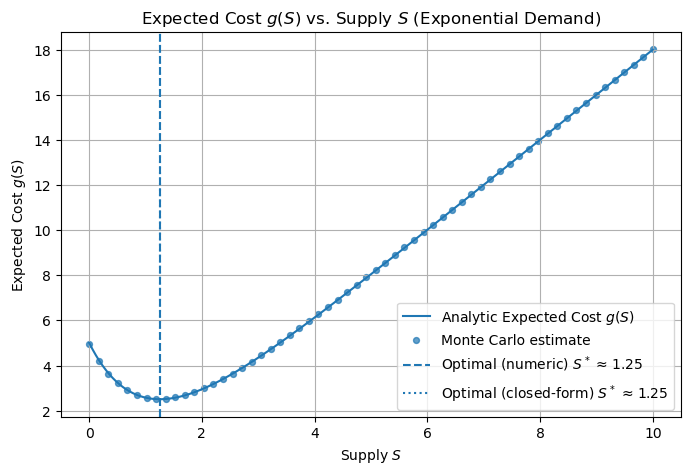

1.252763051167479

In [3]:
result = minimize_scalar(expected_cost, bounds=(0, 10), method='bounded')
optimal_S = result.x
optimal_S_closed = optimal_supply_closed_form(p, h, lambda_param)

# Analytic expected costs
S_values = np.linspace(0, 10, 500)
costs = np.array([expected_cost(S) for S in S_values])

# Monte Carlo simulation of realized costs
np.random.seed(0)
n_samples = 20000
demand_samples = np.random.exponential(scale=1.0/lambda_param, size=n_samples)

def realized_cost(S, x):
    # p * max(x-S,0) + h * max(S-x,0)
    return p * np.maximum(x - S, 0.0) + h * np.maximum(S - x, 0.0)

# simulate on a coarser grid for speed
S_grid_mc = np.linspace(0, 10, 60)
mc_costs = np.array([realized_cost(S, demand_samples).mean() for S in S_grid_mc])

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(S_values, costs, label="Analytic Expected Cost $g(S)$")
plt.scatter(S_grid_mc, mc_costs, s=18, label="Monte Carlo estimate", alpha=0.7)
plt.axvline(optimal_S, linestyle='--', label=f"Optimal (numeric) $S^*$ " + chr(8776) + f" {optimal_S:.2f}")
plt.axvline(optimal_S_closed, linestyle=':', label=f"Optimal (closed-form) $S^*$ " + chr(8776) + f" {optimal_S_closed:.2f}")
plt.xlabel("Supply $S$")
plt.ylabel("Expected Cost $g(S)$")
plt.title("Expected Cost $g(S)$ vs. Supply $S$ (Exponential Demand)")
plt.legend()
plt.grid(True)
plt.show()

optimal_S


## Question 2: Car Sales (Led by Onat Dalmaz)

You must sell your car within a finite window of $N$ days. At the beginning of each day $t \in \{1, \dots, N\}$, you receive a single offer $X_t$ from a dealership, where $\{X_t\}$ are i.i.d. draws from a known continuous distribution $Q$ supported on $[m, M]$, with $0 < m < M$.

After observing $X_t$, you must immediately choose whether to **accept** or **reject** the offer:

- If you **accept** on day $t$, you sell the car immediately and receive payoff $X_t$. The process then terminates.
- If you **reject** on day $t < N$, you keep the car, pay a parking cost $c \ge 0$ at the end of that day, and proceed to day $t+1$.
- On day $N$, you must accept the offer (i.e., rejecting is not allowed).

Your objective is to maximize the expected **net payoff**, defined as the sale price minus the total parking costs paid before the sale.

***

### Part (A): MDP Modeling

Model this problem as a finite-horizon **Markov Decision Process (MDP)**. Clearly specify:

1. **States**
2. **Actions**
3. **Rewards**
4. **State-transition probabilities**
5. **Discount factor** (use $\gamma = 1$)

Also state whether this MDP is finite- or infinite-horizon, episodic or continuing, and whether it is time-homogeneous.

***

### Part (B): Structure of the Optimal Policy

Let $V_t$ denote the optimal value function when there are $t$ days remaining (before observing the offer).

1. Write down the Bellman recursion for $V_t$.
2. Show that the optimal policy is a **time-dependent threshold policy**: that is, there exists a reservation price $r_t$ such that it is optimal to accept an offer $x$ if and only if $x \ge r_t$.
3. Express the threshold $r_t$ in terms of $V_{t-1}$ and $c$.

(You may leave expectations with respect to $Q$ written in integral or expectation form. A closed-form solution for general $Q$ is not required.)

***

### Part (C): Special Case (No Integrals)

Now consider the special case where $c = 0$ and $Q = \text{Uniform}[m, M]$.

1. Write the recursion for $V_t$ explicitly.
2. Provide the optimal policy in as closed-form a way as possible. Your policy may depend on recursively defined coefficients, but your final expressions should contain **no integrals**.


### Part (A) Answer

A clean finite-horizon MDP is obtained by including “days remaining” and the current offer.

- **State:** $(t, x)$ where $t\in\{1,\dots,N\}$ is the number of days remaining and $x\in[m,M]$ is today’s observed offer.
- **Actions:**  
  For $t>1$: $\{\text{Accept}, \text{Reject}\}$;  
  For $t=1$: only $\{\text{Accept}\}$ (forced acceptance).
- **Reward:**  
  If Accept in state $(t,x)$: reward $=x$ and transition to terminal.  
  If Reject in state $(t,x)$ with $t>1$: reward $=-c$ (parking paid at end of day), and transition to next day.
- **Transitions:**  
  If Reject from $(t,x)$ with $t>1$: next offer $x'\sim Q$ i.i.d., so next state is $(t-1, x')$.  
  If Accept: terminal absorbing state.
- **Discount factor:** $\gamma=1$.

**Classification:** finite-horizon, **episodic** (terminates when you accept, and certainly by day $N$). If you *augment* the state with $t$, the dynamics are time-homogeneous in the augmented state; otherwise it is time-inhomogeneous. (Either modeling choice is fine; the optimal policy is the same.)


### Part (B) Answer

Let $V_t$ be the optimal value when there are $t$ days remaining **before observing** today’s offer.

- Base case (last day): you must accept, so
$$
V_1 = \mathbb{E}[X], \quad X\sim Q.
$$

- For $t\ge 2$: after observing offer $X$, you either accept for payoff $X$ or reject, pay $c$, and continue with $t-1$ days remaining:
$$
V_t = \mathbb{E}\!\left[\max\!\big(X,\; V_{t-1}-c\big)\right].
$$

**Threshold structure:** For fixed $t$, rejecting gives the deterministic continuation value $V_{t-1}-c$. Therefore the optimal policy is:
$$
\text{Accept iff } X \ge r_t,
\quad\text{where}\quad
r_t = V_{t-1}-c.
$$

So the reservation price is increasing in how valuable it is to “wait” (large $V_{t-1}$) and decreasing in parking cost $c$.


### Part (C) Answer

Here $c=0$ and $X\sim\text{Uniform}[m,M]$. Let $L=M-m$.

**1) Recursion for $V_t$.**  
Base: $V_1=\mathbb{E}[X]=\dfrac{m+M}{2}$.  
For $t\ge 2$, with threshold $r_t=V_{t-1}$,
$$
V_t=\mathbb{E}[\max(X,V_{t-1})].
$$
For uniform, if $v:=V_{t-1}\in[m,M]$:
$$
V_t=\frac{1}{L}\left(\int_m^v v\,dx+\int_v^M x\,dx\right)
=\frac{M^2+v^2-2mv}{2L}.
$$

A very clean “no integrals” form comes from normalizing:
$$
y_t := \frac{V_t-m}{L}\in[0,1].
$$
Then $y_1=\frac12$ and
$$
y_t=\frac12\Big(1+y_{t-1}^2\Big),\qquad t\ge 2,
$$
and finally $V_t = m + L\,y_t$.

**2) Optimal policy (closed-form-ish).**  
On a day with $t$ days remaining, accept iff
$$
X \ge r_t,\quad r_t = V_{t-1} = m + L\,y_{t-1},
$$
where $\{y_t\}$ is defined by the recursion above.


## Question 3: Constrained Consumption (Led by Onat Dalmaz)

Consider the following discrete-time MDP for constrained consumption. At $t = 0$, the agent is given a finite amount $x_0 \in \mathbb{R}^+$ of a resource. In each time period, the agent can choose to consume any amount of the resource, with the consumption denoted as $c \in [0, x]$ where $x$ is the amount of the resource remaining at the start of the time period. This consumption results in a reduction of the resource at the start of the next time period:  
$$x' = x - c.$$  

Consuming a quantity $c$ of the resource provides a utility of consumption equal to $U(c)$, and we adopt the **CRRA utility function**:  
$$
U(c) = \frac{c^{1 - \gamma}}{1 - \gamma}, \quad (\gamma > 0, \gamma \neq 1)
$$

Our goal is to maximize the aggregate discounted utility of consumption until the resource is completely consumed. We assume a discount factor of $\beta \in (0, 1)$ when discounting the utility of consumption over any single time period. Assume parameters are such that the value function is finite.

We model this as a **discrete-time, continuous-state-space, continuous-action-space, stationary, deterministic MDP**, and so our goal is to solve for the **Optimal Value Function** and associated **Optimal Policy**, which will give us the optimal consumption trajectory of the resource. Since this is a stationary MDP, the **State** is simply the amount $x$ of the resource remaining at the start of a time period. The **Action** is the consumption quantity $c$ in that time period. The **Reward** for a time period is $U(c)$ when the consumption in that time period is $c$. The discount factor over each single time period is $\beta$.

We assume that the **Optimal Policy** is given by:  
$$
c^* = \theta^* \cdot x \quad \text{for some } \theta^* \in [0, 1].
$$

***

### Part (A): Closed-form Expression for $V_\theta(x)$

Our first step is to consider a fixed deterministic policy, given by:  
$$c = \theta \cdot x \quad \text{for some fixed } \theta \in [0, 1].$$  
Derive a closed-form expression for the **Value Function** $V_\theta(x)$ for a fixed deterministic policy, given by $c = \theta \cdot x$. Specifically, you need to express $V_\theta(x)$ in terms of $\beta$, $\gamma$, $\theta$, and $x$.

***

### Part (B): Solving for $\theta^*$

Use this closed-form expression for $V_\theta(x)$ to solve for the $\theta^*$ which maximizes $V_\theta(x)$ (thus fetching us the **Optimal Policy** given by $c^* = \theta^* \cdot x$).

***

### Part (C): Expression for $V^*(x)$

Use this expression for $\theta^*$ to obtain an expression for the **Optimal Value Function** $V^*(x)$ in terms of only $\beta$, $\gamma$, and $x$.

***

### Part (D): Validation of the Bellman Equation

Validate that the **Optimal Policy** (derived in part B) and **Optimal Value Function** (derived in part C) satisfy the **Bellman Optimality Equation**.

### Part (A) Answer

Fix $\theta\in[0,1]$ and use the deterministic policy $c_t=\theta x_t$.

Dynamics:
$$
x_{t+1}=x_t-c_t=(1-\theta)x_t \;\Rightarrow\; x_t=(1-\theta)^t x.
$$
So consumption is
$$
c_t=\theta x_t=\theta(1-\theta)^t x.
$$

CRRA utility:
$$
U(c_t)=\frac{c_t^{1-\gamma}}{1-\gamma}
=\frac{\theta^{1-\gamma}(1-\theta)^{t(1-\gamma)}x^{1-\gamma}}{1-\gamma}.
$$

Thus the value function is a geometric series:
$$
V_\theta(x)=\sum_{t=0}^\infty \beta^t U(c_t)
=\frac{\theta^{1-\gamma}x^{1-\gamma}}{1-\gamma}\sum_{t=0}^\infty\Big(\beta(1-\theta)^{1-\gamma}\Big)^t.
$$

Assuming $\beta(1-\theta)^{1-\gamma}<1$,
$$
V_\theta(x)=\frac{\theta^{1-\gamma}x^{1-\gamma}}{(1-\gamma)\Big(1-\beta(1-\theta)^{1-\gamma}\Big)}.
$$


### Part (B) Answer

We maximize $V_\theta(x)$ over $\theta\in[0,1]$. Since $x^{1-\gamma}/(1-\gamma)$ is a constant factor independent of $\theta$, it suffices to maximize
$$
J(\theta)=\frac{\theta^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}.
$$

A faster route is to use the deterministic Euler condition for the optimal consumption path:
$$
U'(c_t) = \beta\,U'(c_{t+1}).
$$
For CRRA, $U'(c)=c^{-\gamma}$, so
$$
c_t^{-\gamma}=\beta\,c_{t+1}^{-\gamma}
\;\Rightarrow\;
\frac{c_{t+1}}{c_t}=\beta^{1/\gamma}.
$$

Under the constant-fraction policy, $c_{t+1}=\theta x_{t+1}=\theta(1-\theta)x_t=(1-\theta)c_t$, hence
$$
1-\theta^*=\beta^{1/\gamma}
\quad\Rightarrow\quad
\boxed{\;\theta^*=1-\beta^{1/\gamma}\;}
$$
(which lies in $[0,1]$ since $\beta\in(0,1)$).


### Part (C) Answer

Plug $\theta^*=1-\beta^{1/\gamma}$ into the closed-form from Part (A).

Note $1-\theta^*=\beta^{1/\gamma}$, so
$$
1-\beta(1-\theta^*)^{1-\gamma}
=1-\beta\cdot\left(\beta^{1/\gamma}\right)^{1-\gamma}
=1-\beta^{1/\gamma}.
$$

Therefore
$$
V^*(x)=\frac{(\theta^*)^{1-\gamma}x^{1-\gamma}}{(1-\gamma)\left(1-\beta^{1/\gamma}\right)}
=\frac{(1-\beta^{1/\gamma})^{1-\gamma}}{(1-\gamma)(1-\beta^{1/\gamma})}\,x^{1-\gamma}
=\boxed{\;\frac{x^{1-\gamma}}{1-\gamma}\,(1-\beta^{1/\gamma})^{-\gamma}\;}
$$


### Part (D) Answer

Let $V^*(x)=Kx^{1-\gamma}$ with
$$
K=\frac{(1-\beta^{1/\gamma})^{-\gamma}}{1-\gamma}.
$$

Bellman optimality equation:
$$
V^*(x)=\max_{c\in[0,x]}\left\{\frac{c^{1-\gamma}}{1-\gamma}+\beta V^*(x-c)\right\}
=\max_{0\le y\le 1}\left\{\frac{(yx)^{1-\gamma}}{1-\gamma}+\beta K\big((1-y)x\big)^{1-\gamma}\right\}.
$$
Divide by $x^{1-\gamma}$:
$$
K=\max_{0\le y\le 1}\left\{\frac{y^{1-\gamma}}{1-\gamma}+\beta K(1-y)^{1-\gamma}\right\}.
$$

FOC w.r.t. $y$:
$$
y^{-\gamma}-\beta K(1-\gamma)(1-y)^{-\gamma}=0
\;\Rightarrow\;
\left(\frac{y}{1-y}\right)^{\gamma}=\frac{1}{\beta K(1-\gamma)}.
$$
Using $K(1-\gamma)=(1-\beta^{1/\gamma})^{-\gamma}$, we get
$$
\left(\frac{y}{1-y}\right)^{\gamma}=\frac{(1-\beta^{1/\gamma})^{\gamma}}{\beta}
\quad\Rightarrow\quad
\frac{y}{1-y}=\frac{1-\beta^{1/\gamma}}{\beta^{1/\gamma}}
\quad\Rightarrow\quad
y^*=1-\beta^{1/\gamma}.
$$
So the maximizing control is $c^*=y^*x=\theta^*x$ with $\theta^*$ from Part (B).

Plugging $y^*$ back into the RHS yields exactly $K$ above (equivalently, it matches the geometric-series value computed in Part (C)), so $(V^*,\pi^*)$ satisfies the Bellman equation.


## Problem 4: Double Q-Learning (Led by Onat Dalmaz)

It is known that **Q-Learning** can suffer from maximization bias during finite-sample training. In this problem, we consider a modification of tabular Q-Learning called **Double Q-Learning**, which reduces this bias by decoupling action selection and evaluation.

***

### **Algorithm 1: Double Q-Learning**

**Initialize** $Q_1(s,a)$ and $Q_2(s,a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}$  
**yield** estimate of $Q$

**while** True **do**  
 **select** initial state $s_0$, set $t = 0$  
 **while** $s_t$ is non-terminal **do**  

 **select** $a_t$ using $\epsilon$-greedy with respect to  
 $\displaystyle \pi(s) = \arg\max_a \big( Q_1(s,a) + Q_2(s,a) \big)$  

 **observe** $(r_t, s_{t+1})$  

 **with probability 0.5 update $Q_1$:**

 Let  
 $\displaystyle a^* = \arg\max_a Q_1(s_{t+1}, a)$  

 Update  
 $\displaystyle 
Q_1(s_t, a_t) \leftarrow Q_1(s_t, a_t)
+ \alpha \Big(
r_t + \gamma Q_2(s_{t+1}, a^*)
- Q_1(s_t, a_t)
\Big)
$

 **otherwise update $Q_2$:**

 Let  
 $\displaystyle a^* = \arg\max_a Q_2(s_{t+1}, a)$  

 Update  
 $\displaystyle 
Q_2(s_t, a_t) \leftarrow Q_2(s_t, a_t)
+ \alpha \Big(
r_t + \gamma Q_1(s_{t+1}, a^*)
- Q_2(s_t, a_t)
\Big)
$

 $t \leftarrow t + 1$  
 $s_t \leftarrow s_{t+1}$  

**yield** estimate $Q_1 + Q_2$

***

### **Algorithm 2: Q-Learning**

**Initialize** $Q(s,a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}$  
**yield** $Q$

**while** True **do**  
 **select** initial state $s_0$, set $t = 0$  
 **while** $s_t$ is non-terminal **do**  

 **select** $a_t$ using $\epsilon$-greedy with respect to  
 $\displaystyle \pi(s) = \arg\max_a Q(s,a)$  

 **observe** $(r_t, s_{t+1})$  

 Update  
 $\displaystyle 
Q(s_t, a_t) \leftarrow Q(s_t, a_t)
+ \alpha \Big(
r_t + \gamma \max_a Q(s_{t+1}, a)
- Q(s_t, a_t)
\Big)
$

 $t \leftarrow t + 1$  
 $s_t \leftarrow s_{t+1}$  

**yield** $Q$

***

### Instructions

The code skeleton for this problem is provided below. Implement the functions:

- `double_q_learning`
- `q_learning`

After running both algorithms, you will obtain a plot of the estimated Q-value versus episode number.

In your writeup:

1. Compare the behavior of Q-Learning and Double Q-Learning.
2. Explain why Q-Learning can exhibit maximization bias.
3. Discuss the advantages and possible drawbacks of Double Q-Learning in general MDPs.


***

### Writeup (Q-Learning vs Double Q-Learning)

**1) What you should see in the plot:**  
Standard Q-learning tends to push $Q(A,a1)$ *too high* (often positive), even though the true expected return of taking $a_1$ from $A$ is $-0.1$ (and the optimal action at $A$ is $a_2$, which yields $0$ and terminates). Double Q-learning stays much closer to the ground truth because it dampens the over-optimistic updates.

**2) Why maximization bias happens:**  
Q-learning uses the same noisy estimates both to **select** the maximizing action and to **evaluate** it:
$$
r+\gamma\max_{a'} Q(s',a').
$$
Because $\max$ is convex, $\mathbb{E}[\max_a \hat{q}_a]\ge \max_a \mathbb{E}[\hat{q}_a]$ when $\hat{q}_a$ are noisy. In this toy MDP, state $B$ has many actions with i.i.d. reward noise, so “taking the max” over $n$ noisy estimates is systematically biased upward, and that inflated value backs up into $Q(A,a1)$.

**3) Why Double Q-learning helps (and tradeoffs):**  
Double Q-learning splits estimation into $(Q_1,Q_2)$ and uses one table to pick the argmax and the other to evaluate it. This makes the selection noise and evaluation noise less coupled, reducing the upward bias.

Drawbacks in general:
- you maintain (and update) **two** value tables (more memory / compute),
- learning can be a bit **slower** early on (each table sees fewer updates),
- with function approximation (NNs), the two estimators can become correlated again, so bias reduction may be imperfect (still usually better than plain DQN/Q-learning).


In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from collections import defaultdict
from typing import Mapping, Iterator, TypeVar, Tuple, Dict, Iterable, Generic

# RL imports (adapt or remove if you don't have the same environment):
from rl.distribution import (
    Distribution, Constant, Gaussian, Choose, SampledDistribution, Categorical
)
from rl.markov_process import NonTerminal, State, Terminal
from rl.markov_decision_process import MarkovDecisionProcess
from rl.td import epsilon_greedy_action

S = TypeVar('S')
A = TypeVar('A')

In [5]:
# -----------------------------------------------------------------------
# Tabular Q-value function approximation (done for you)
# -----------------------------------------------------------------------
class TabularQValueFunctionApprox(Generic[S, A]):
    """
    A basic implementation of a tabular function approximation 
    with constant learning rate of 0.1
    Also tracks the number of updates per (state, action).
    """
    def __init__(self):
        self.counts: Mapping[Tuple[NonTerminal[S], A], int] = defaultdict(int)
        self.values: Mapping[Tuple[NonTerminal[S], A], float] = defaultdict(float)
    
    def update(self, k: Tuple[NonTerminal[S], A], target: float) -> None:
        alpha = 0.1
        old_val = self.values[k]
        self.values[k] = (1 - alpha) * old_val + alpha * target
        self.counts[k] += 1
    
    def __call__(self, x: Tuple[NonTerminal[S], A]) -> float:
        return self.values[x]

In [6]:
# -----------------------------------------------------------------------
# Double Q-Learning (fill in)
# -----------------------------------------------------------------------
def double_q_learning(
    mdp: MarkovDecisionProcess[S, A],
    states: Distribution[NonTerminal[S]],
    gamma: float,
    epsilon: float = 0.1
) -> Iterator[TabularQValueFunctionApprox[S, A]]:
    """
    Implements Double Q-Learning:
      1) Keep two Q tables, Q1 and Q2.
      2) Choose actions epsilon-greedily w.r.t. Q1+Q2.
      3) With 50% chance update Q1 using next action from argmax(Q1),
         but evaluate with Q2; otherwise swap roles.
    Yields (Q1 + Q2) after each episode.
    """
    Q1 = TabularQValueFunctionApprox[S, A]()
    Q2 = TabularQValueFunctionApprox[S, A]()

    def _sample(dist: Distribution):
        # RL-book Distributions typically have .sample(); fall back to calling
        if hasattr(dist, "sample"):
            return dist.sample()  # type: ignore
        return dist()  # type: ignore

    def _epsilon_greedy_action(state: NonTerminal[S]) -> A:
        acts = list(mdp.actions(state))
        if len(acts) == 0:
            raise ValueError("No actions available from state")
        if random.random() < epsilon:
            return random.choice(acts)

        # greedy wrt Q1+Q2
        best_a = acts[0]
        best_v = Q1((state, best_a)) + Q2((state, best_a))
        for a in acts[1:]:
            v = Q1((state, a)) + Q2((state, a))
            if v > best_v:
                best_v, best_a = v, a
        return best_a

    def _argmax(q: TabularQValueFunctionApprox[S, A], state: NonTerminal[S]) -> A:
        acts = list(mdp.actions(state))
        best_a = acts[0]
        best_v = q((state, best_a))
        for a in acts[1:]:
            v = q((state, a))
            if v > best_v:
                best_v, best_a = v, a
        return best_a

    def _combined_Q() -> TabularQValueFunctionApprox[S, A]:
        Qsum = TabularQValueFunctionApprox[S, A]()
        for k, v in Q1.values.items():
            Qsum.values[k] += v
        for k, v in Q2.values.items():
            Qsum.values[k] += v
        return Qsum

    while True:
        # Start a fresh episode
        s: State[S] = _sample(states)
        if not isinstance(s, NonTerminal):
            yield _combined_Q()
            continue

        s_nt: NonTerminal[S] = s

        # Roll out until terminal
        while isinstance(s_nt, NonTerminal):
            a = _epsilon_greedy_action(s_nt)
            next_state, r = _sample(mdp.step(s_nt, a))

            if isinstance(next_state, NonTerminal):
                if random.random() < 0.5:
                    a_star = _argmax(Q1, next_state)
                    target = r + gamma * Q2((next_state, a_star))
                    Q1.update((s_nt, a), target)
                else:
                    a_star = _argmax(Q2, next_state)
                    target = r + gamma * Q1((next_state, a_star))
                    Q2.update((s_nt, a), target)
                s_nt = next_state
            else:
                # terminal next state: bootstrap term is 0
                if random.random() < 0.5:
                    Q1.update((s_nt, a), r)
                else:
                    Q2.update((s_nt, a), r)
                break

        yield _combined_Q()


In [7]:
# -----------------------------------------------------------------------
# Standard Q-Learning (fill in)
# -----------------------------------------------------------------------
def q_learning(
    mdp: MarkovDecisionProcess[S, A],
    states: Distribution[NonTerminal[S]],
    gamma: float,
    epsilon: float = 0.1
) -> Iterator[TabularQValueFunctionApprox[S, A]]:
    """
    Standard Q-Learning:
      1) Keep one Q table
      2) Epsilon-greedy wrt that table
      3) Update Q((s,a)) with  r + gamma * max_{a'} Q((s_next, a'))
    Yields Q after each episode.
    """
    Q = TabularQValueFunctionApprox[S, A]()

    def _sample(dist: Distribution):
        if hasattr(dist, "sample"):
            return dist.sample()  # type: ignore
        return dist()  # type: ignore

    def _epsilon_greedy_action(state: NonTerminal[S]) -> A:
        acts = list(mdp.actions(state))
        if len(acts) == 0:
            raise ValueError("No actions available from state")
        if random.random() < epsilon:
            return random.choice(acts)

        best_a = acts[0]
        best_v = Q((state, best_a))
        for a in acts[1:]:
            v = Q((state, a))
            if v > best_v:
                best_v, best_a = v, a
        return best_a

    def _max_q(state: NonTerminal[S]) -> float:
        acts = list(mdp.actions(state))
        return max(Q((state, a)) for a in acts)

    while True:
        s: State[S] = _sample(states)
        if not isinstance(s, NonTerminal):
            yield Q
            continue

        s_nt: NonTerminal[S] = s

        while isinstance(s_nt, NonTerminal):
            a = _epsilon_greedy_action(s_nt)
            next_state, r = _sample(mdp.step(s_nt, a))

            if isinstance(next_state, NonTerminal):
                target = r + gamma * _max_q(next_state)
                Q.update((s_nt, a), target)
                s_nt = next_state
            else:
                Q.update((s_nt, a), r)
                break

        yield Q


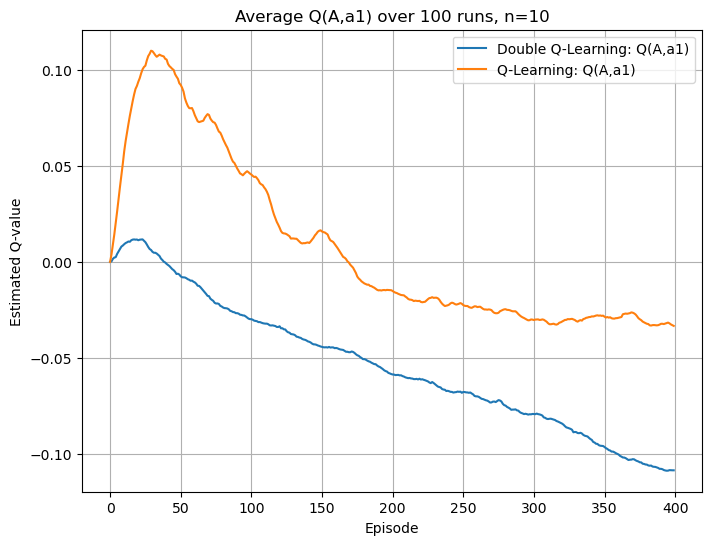

In [8]:
# -----------------------------------------------------------------------
# The MDP: States A,B and actions a1,a2,b1,...,bn (don't modify anything anymore, just run to get the graphs)
# -----------------------------------------------------------------------
@dataclass(frozen=True)
class P1State:
    """
    The MDP state, storing whether we are in "A" or "B".
    """
    name: str

class P1MDP(MarkovDecisionProcess[P1State, str]):
    
    def __init__(self, n: int):
        self.n = n

    def actions(self, state: NonTerminal[P1State]) -> Iterable[str]:
        """
        Return the actions available from this state.
          - if state is A => ["a1", "a2"]
          - if state is B => ["b1", ..., "bn"]
        """
        if state.state.name == "A":
            return ["a1", "a2"]
        else:
            return [f"b{i}" for i in range(1, self.n+1)]
    
    def step(
        self,
        state: NonTerminal[P1State],
        action: str
    ) -> Distribution[Tuple[State[P1State], float]]:
        """
        Return the distribution of (next state, reward) from (state, action):
          - A + a1 => reward 0, next state B
          - A + a2 => reward 0, next state terminal
          - B + b_i => reward ~ Normal(-0.1,1), next state terminal
        """
        if state.state.name == "A":
            if action == "a1":
                return Constant((NonTerminal(P1State("B")), 0.0))
            else:
                return Constant((Terminal(P1State("T")), 0.0))
        else:
            # For B + b_i => reward ~ N(-0.1,1), then terminal
            def sampler():
                r = np.random.normal(loc=-0.1, scale=1.0)
                return (Terminal(P1State("T")), r)
            return SampledDistribution(sampler)

def run_double_q_once(mdp, start_dist, gamma=1.0, episodes=400):
    """
    Runs one 'chain' of Double Q-Learning for 'episodes' episodes,
    returning a list of Q-values for Q((A,a1)) at the end of each episode.
    """
    dq_iter = double_q_learning(mdp, start_dist, gamma)  # generator
    vals = []
    for _ in range(episodes):
        Q1 = next(dq_iter)
        # record Q1((A,a1)) each time
        qA1 = Q1((NonTerminal(P1State("A")), "a1"))
        vals.append(qA1)
    return vals

def run_q_once(mdp, start_dist, gamma=1.0, episodes=400):
    """
    Same but for standard Q-Learning
    """
    q_iter = q_learning(mdp, start_dist, gamma)
    vals = []
    for _ in range(episodes):
        Q = next(q_iter)
        qA1 = Q((NonTerminal(P1State("A")), "a1"))
        vals.append(qA1)
    return vals

def main():
    # For reproducibility
    random.seed(0)
    np.random.seed(0)

    n = 10
    mdp = P1MDP(n)
    # Always start in A, as a NonTerminal
    start_dist = Constant(NonTerminal(P1State("A")))

    N_RUNS = 100
    N_EPISODES = 400

    all_dbl = []
    all_std = []

    for _ in range(N_RUNS):
        dbl_vals = run_double_q_once(mdp, start_dist, gamma=1.0, episodes=N_EPISODES)
        std_vals = run_q_once(mdp, start_dist, gamma=1.0, episodes=N_EPISODES)
        all_dbl.append(dbl_vals)
        all_std.append(std_vals)

    arr_dbl = np.array(all_dbl)
    arr_std = np.array(all_std)

    avg_dbl = np.mean(arr_dbl, axis=0)
    avg_std = np.mean(arr_std, axis=0)

    plt.figure(figsize=(8,6))
    plt.plot(avg_dbl, label='Double Q-Learning: Q(A,a1)')
    plt.plot(avg_std, label='Q-Learning: Q(A,a1)')
    plt.xlabel('Episode')
    plt.ylabel('Estimated Q-value')
    plt.title('Average Q(A,a1) over 100 runs, n=10')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()